In [456]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

Импорт датасета

In [457]:
df = pd.read_csv("./datasets/_data.csv")

График распределения значений NaN

In [458]:
df.replace(["NaN", "nan", "", "NULL"], pd.NA, inplace=True)

,Unnamed: 0,ID объявления,Количество комнат,Тип,Метро,Адрес,"Площадь, м2",Дом,Парковка,Цена,...,Окна,Санузел,Можно с детьми/животными,Дополнительно,Название ЖК,Серия дома,"Высота потолков, м",Лифт,Мусоропровод,Ссылка на объявление
0,0,271271157,4,Квартира,м. Смоленская (9 мин пешком),"Москва, улица Новый Арбат, 27",200.0/20.0,"5/16, Монолитный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",...,NaN,NaN,"Можно с детьми, Можно с животными","Мебель в комнатах, Мебель на кухне, Ванна, Душ...","Новый Арбат, 2010",NaN,3.00,"Пасс (4), Груз (1)",Да,https://www.cian.ru/rent/flat/271271157
1,1,271634126,4,Квартира,м. Смоленская (8 мин пешком),"Москва, улица Новый Арбат, 27",198.0/95.0/18.0,"5/16, Монолитно-кирпичный",подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",...,На улицу и двор,"Совмещенный (2), Раздельный (1)",Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.50,"Пасс (1), Груз (1)",Нет,https://www.cian.ru/rent/flat/271634126
2,2,271173086,"4, Оба варианта",Квартира,м. Смоленская (7 мин пешком),"Москва, улица Новый Арбат, 27",200.0/116.0/4.0,5/16,подземная,"500000.0 руб./ За месяц, Залог - 500000 руб., ...",...,На улицу и двор,Совмещенный (3),Можно с детьми,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",Новый Арбат,NaN,3.20,Пасс (1),NaN,https://www.cian.ru/rent/flat/271173086
3,3,272197456,"4, Оба варианта",Квартира,м. Смоленская (3 мин пешком),"Москва, переулок Плотников, 21С1",170.0/95.0/17.0,5/6,подземная,"400000.0 руб./ За месяц, Залог - 400000 руб., ...",...,На улицу и двор,Совмещенный (3),Можно с животными,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",NaN,NaN,3.20,Пасс (1),NaN,https://www.cian.ru/rent/flat/272197456
4,4,273614615,2,Квартира,м. Арбатская (7 мин пешком),"Москва, улица Новый Арбат, 15",58.0/38.0/5.0,"12/26, Панельный",NaN,"225000.0 руб./ За месяц, Залог - 225000 руб., ...",...,На улицу и двор,Совмещенный (2),NaN,"Мебель в комнатах, Мебель на кухне, Ванна, Душ...",The Book,NaN,3.90,"Пасс (1), Груз (1)",Да,https://www.cian.ru/rent/flat/273614615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23363,23363,215565511,NaN,Квартира,м. Говорово (8 мин пешком),"Москва, Боровское шоссе, 2к7, ш. Боровское (3 ...",35.0/16.4/8.0,10/14,NaN,"42000.0 руб./ За месяц, Залог - 42000 руб., Ко...",...,NaN,Совмещенный (1),NaN,"Мебель в комнатах, Мебель на кухне, Ванна, Сти...",Мещерский лес,NaN,NaN,"Пасс (1), Груз (1)",NaN,https://www.cian.ru/rent/flat/215565511
23364,23364,274654844,1,Квартира,м. Солнцево (7 мин пешком),"Москва, Производственная улица, 8к1, ш. Боровс...",38.7/16.5/11.0,"5/18, Монолитный",NaN,"45000.0 руб./ За месяц, Залог - 45000 руб., Ко...",...,Во двор,Совмещенный (1),NaN,"Мебель в комнатах, Мебель на кухне, Ванна, Сти...",Лучи,NaN,NaN,"Пасс (1), Груз (1)",NaN,https://www.cian.ru/rent/flat/274654844
23365,23365,268679909,"2, Оба варианта",Квартира,м. Солнцево (6 мин пешком),"Москва, Боровский проезд, 11",43.1,"5/5, Кирпичный",NaN,"50000.0 руб./ За месяц, Залог - 50000 руб., Ко...",...,На улицу и двор,Совмещенный (1),Можно с детьми,"Мебель на кухне, Душевая кабина, Стиральная ма...",NaN,NaN,NaN,NaN,NaN,https://www.cian.ru/rent/flat/268679909
23366,23366,274807525,2,Квартира,м. Солнцево (11 мин пешком),"Москва, улица Богданова, 6к1, ш. Боровское (3 ...",52.5/10.0,"8/23, Монолитный",наземная,"55000.0 руб./ За месяц, Залог - 50000 руб., Ко...",...,Во двор,"Совмещенный (1), Раздельный (1)",NaN,"Мебель в комнатах, Мебель на кухне, Ванна, Сти...",NaN,NaN,2.65,Пасс (3),Да,https://www.cian.ru/rent/flat/274807525


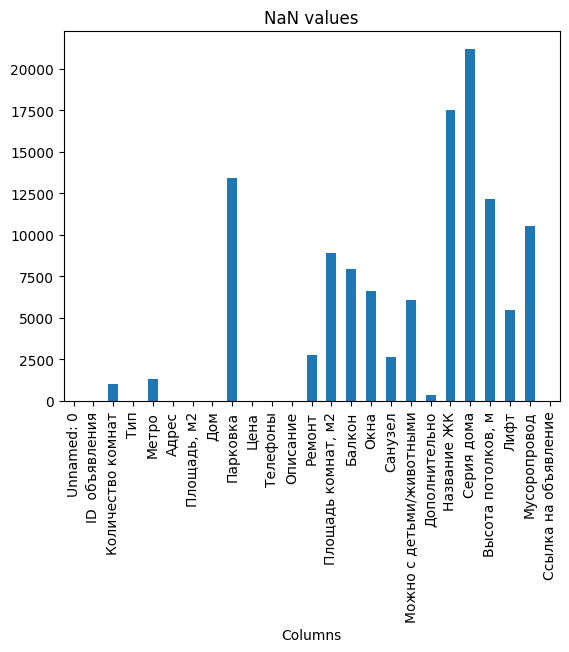

In [459]:
nan = df.isna().sum()
nan.plot(kind='bar')
plt.title("NaN values")
plt.xlabel('Columns')
plt.show()

Процент пустых значений для столбцов

In [460]:
df.isna().mean()

Unnamed: 0                  0.000000
ID  объявления              0.000000
Количество комнат           0.044548
Тип                         0.000000
Метро                       0.056274
Адрес                       0.000000
Площадь, м2                 0.000000
Дом                         0.000000
Парковка                    0.574161
Цена                        0.000000
Телефоны                    0.000000
Описание                    0.000000
Ремонт                      0.117896
Площадь комнат, м2          0.381291
Балкон                      0.341407
Окна                        0.282994
Санузел                     0.114344
Можно с детьми/животными    0.260870
Дополнительно               0.015277
Название ЖК                 0.749743
Серия дома                  0.907438
Высота потолков, м          0.520455
Лифт                        0.235365
Мусоропровод                0.450274
Ссылка на объявление        0.000000
dtype: float64

Очистка и предобработка датафрейма 

In [461]:
# Удаление колонок с маловажной информаций 
drop_columns = ['Тип','Телефоны', 'Описание', 'Площадь комнат, м2', 'Окна', 'Санузел',
       'Можно с детьми/животными', 'Дополнительно', 'Название ЖК', 'Серия дома',
       'Высота потолков, м','Мусоропровод',
       'Ссылка на объявление']
df.drop(columns=drop_columns, inplace=True)

In [462]:
#оставляем только количество комнат и убираем лишние слова
def clean_rooms(value):
    
    if pd.isna(value):
        return None
    #первое число в строке
    match = re.search(r'(\d+)', str(value))
    return int(match.group(1)) if match else None

df['Количество комнат'] = df['Количество комнат'].apply(clean_rooms)
df['Количество комнат'] = pd.to_numeric(df['Количество комнат'], errors='coerce').astype('Int64')
df['Количество комнат'] = df['Количество комнат'].fillna(0)


In [463]:
#выделение города из адреса
df[['Город', 'Адрес']]=df['Адрес'].str.split(',', n=1, expand=True)
df['Город']=df['Город'].str.strip()
df['Адрес']=df['Адрес'].str.strip()

# сохранение результата без СПб и Краснодара
df=df[~((df['Город']=='Санкт-Петербург') | (df['Город']=='Краснодарский край'))]
df = df.drop('Город', axis=1)

In [464]:
# Убираем лишнее в конце адреса
# 'Производственная улица, 8к1, ш. Боровское (5 км до МКАД), ш. Киевское (7 км до МКАД)'
df['Адрес'] = df['Адрес'].str.split(', ш. ').str[0]

In [465]:
# Выделение столбцов этаж квартиры, этажность дома, тип дома
df[['этажи', 'тип_дома']] = df['Дом'].str.split(',', n=1, expand=True)
df[['этаж_квартиры', 'этажность_дома']] = df['этажи'].str.split('/', n=1, expand=True)

df['этаж_квартиры'] = df['этаж_квартиры'].str.strip()
df['этажность_дома'] = df['этажность_дома'].str.strip()
df['тип_дома'] = df['тип_дома'].str.strip()

df = df.drop('этажи', axis=1)
df = df.drop('Дом', axis=1)

In [466]:
#Заполняем пустоты у типа дома
df['тип_дома']=df['тип_дома'].fillna('Неизвестен')

In [467]:
#Приведение лифтов к бинарному значению
df['Лифт'] = df['Лифт'].fillna(0)
df['Лифт'] = df['Лифт'].astype(bool).astype(int)

#Приведение паркинга к бинарному значению
df['Парковка'] = df['Парковка'].fillna(0)
df['Парковка'] = df['Парковка'].astype(bool).astype(int)

#площадь разобъем на три колонки "общую", "жилую" и "кухню"

In [468]:
def split_area(area_str):
    if pd.isna(area_str):
        return pd.Series([None, None, None])
    parts = str(area_str).split('/')
    total = float(parts[0]) if len(parts) > 0 else None
    living = float(parts[1]) if len(parts) > 1 else None
    kitchen = float(parts[2]) if len(parts) > 2 else None
    return pd.Series([total, living, kitchen])
#теперь сама функция
df[['Площадь_общая', 'Площадь_жилая', 'Площадь_кухня']] = df['Площадь, м2'].apply(split_area)

In [469]:
#теперь уберем изначальную колонку площадь и NaN из новых колонок
df.drop('Площадь_кухня', axis=1, inplace=True)
df.drop('Площадь_жилая', axis=1, inplace=True)
df.drop('Площадь, м2', axis=1, inplace=True)

In [470]:
#сначала разделим балкон на 2 колонки "Балкон" и "Лоджия" и там где NaN поставим значение 0
def split_categorical_column(df, column_name, categories_dict):
    df_result = df.copy()
    
    for new_col, keyword in categories_dict.items():
        def get_count_for_keyword(value, kw):
            if pd.isna(value):
                return 0
            text = str(value).lower()
            pattern = rf'{kw}[\w]*\s*\((\d+)\)'
            match = re.search(pattern, text)
            if match:
                return int(match.group(1))
            elif kw[:4] in text:
                return 1
            return 0
    
        df_result[new_col] = df[column_name].apply(
            lambda x, k=keyword: get_count_for_keyword(x, k)
        )

    def extract_any_count(value):
        if pd.isna(value):
            return 0
        matches = re.findall(r'\((\d+)\)', str(value))
        if matches:
            return int(matches[0])
        return 0
    
    df_result[f'{column_name}'] = df[column_name].apply(extract_any_count)
    
    return df_result

categories = {
    'Балкон': 'балкон',
    'Лоджия': 'лоджия',
}

df = split_categorical_column(df, 'Балкон', categories)

In [471]:
#обработка столбца с ремонтом и приведение к int значениям
def classify_repir(value):
    if pd.isna(value):
        return 0
    if value == 'Дизайнерский':
        return 4
    if value == 'Евроремонт':
        return 3
    if value == 'Косметический':
        return 2
    if value == 'Без ремонта':
        return 1
    
df['Ремонт'] = df['Ремонт'].apply(classify_repir)

In [472]:
# Обработка цены
def get_price(x) -> int :
    x = x.split('/')[0]
    price = int(x.split('.')[0])
    if not "руб." in x:
        if x[-1] == '€' :
            price *= 90 #  Euro to rubble
        elif x[-1] == '$' :
            price *= 80 # Dollar to rubble
        else :
            print("Unknown currency: ", x)
    return price

df['Цена'] = df['Цена'].apply(lambda x: get_price(x))

Выявление экстремумов в ценах

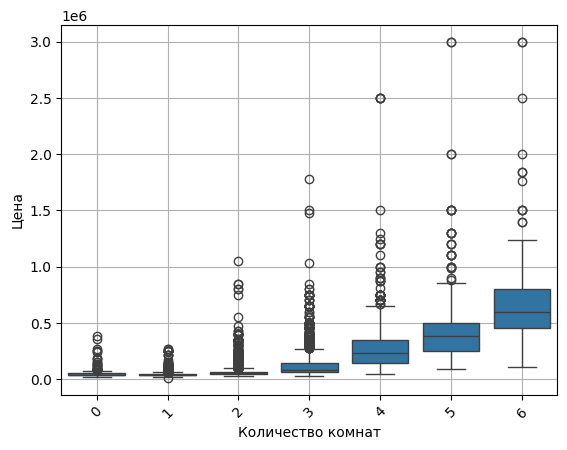

                    count           mean            std       min       25%  \
Количество комнат                                                             
0                   535.0   48481.072897   33423.229858   17500.0   34495.0   
1                  6655.0   41196.689406   15922.699453   12000.0   33000.0   
2                  7407.0   61670.525044   43802.730548   23999.0   42000.0   
3                  3668.0  122120.330698  108988.152016   25000.0   60000.0   
4                  1011.0  278585.548961  235376.260375   45000.0  140000.0   
5                   333.0  455460.447447  359847.509855   89000.0  250000.0   
6                   128.0  723437.492188  495584.000101  110000.0  450000.0   

                        50%       75%        max  
Количество комнат                                 
0                   40000.0   52000.0   380000.0  
1                   38000.0   45000.0   270000.0  
2                   50000.0   65000.0  1050000.0  
3                   80000.0  1450

In [473]:
sns.boxplot(data=df, x='Количество комнат', y = 'Цена')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print(df.groupby('Количество комнат')['Цена'].describe())

In [474]:
print(f"{95}% процентиль: {df.groupby('Количество комнат')['Цена'].quantile(95/100)}")
print(f"{5}% процентиль: {df.groupby('Количество комнат')['Цена'].quantile(5/100)}")

95% процентиль: Количество комнат
0      80300.0
1      65000.0
2     120000.0
3     310000.0
4     700000.0
5    1140000.0
6    1669000.0
Name: Цена, dtype: float64
5% процентиль: Количество комнат
0     26000.0
1     27000.0
2     35000.0
3     45000.0
4     79000.0
5    148000.0
6    193500.0
Name: Цена, dtype: float64


In [475]:
# отдельно смотрим для 6к кв так как подозрительно низкая цена в 5% процентиле
df_6rooms = df[df['Количество комнат'] == 6]['Цена'].sort_values()
df_6rooms.head(10)

22838    110000
7522     149999
15960    150000
10628    150000
18580    150000
12844    180000
6901     190000
15963    200000
17934    200000
8625     230000
Name: Цена, dtype: int64

In [476]:
# отрезаем выбросы макс/мин 5% сверху и снизу

thresholds = {
    1: (27000, 65000),    # для 1-комнатных: от 27 до 65 тыс
    2: (35000, 120000),   # для 2-комнатных: от 35 до 120 тыс
    3: (45000, 300000),   # для 3-комнатных: от 45 до 300 тыс
    4: (75000, 650000),   # для 4-комнатных: от 75 до 650 тыс
    5: (108500, 750000),  # для 5-комнатных: от 108,5 до 750 тыс
    6: (110000, 1000000)   # для 6-комнатных: от 110 до 1000 тыс 
}

def filter_by_thresholds(row):
    rooms = row['Количество комнат']
    price = row['Цена']
    
    if rooms in thresholds:
        low, high = thresholds[rooms]
        return low <= price <= high
    return True  

# Применяем фильтр
df = df[df.apply(filter_by_thresholds, axis=1)]


print(f"Стало записей: {len(df)}")


Стало записей: 18158


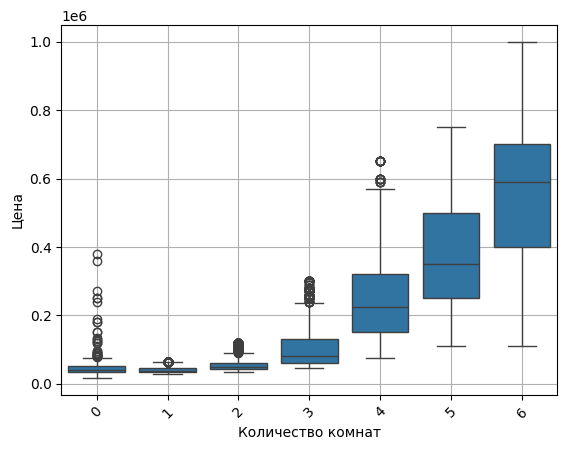

                    count           mean            std       min       25%  \
Количество комнат                                                             
0                   535.0   48481.072897   33423.229858   17500.0   34495.0   
1                  6087.0   39415.703138    8662.581625   27000.0   33000.0   
2                  6835.0   55243.104316   17935.822294   35000.0   43000.0   
3                  3383.0  105129.435117   59173.173176   45000.0   60000.0   
4                   918.0  246707.392157  127690.061379   75000.0  150000.0   
5                   291.0  369626.422680  152922.652436  110000.0  250000.0   
6                   109.0  559853.201835  221338.070379  110000.0  400000.0   

                        50%       75%        max  
Количество комнат                                 
0                   40000.0   52000.0   380000.0  
1                   38000.0   45000.0    65000.0  
2                   50000.0   62000.0   120000.0  
3                   80000.0  1300

In [477]:
# распределение после очистки от выбросов
sns.boxplot(data=df, x='Количество комнат', y = 'Цена')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
print(df_filtered.groupby('Количество комнат')['Цена'].describe())

<Axes: >

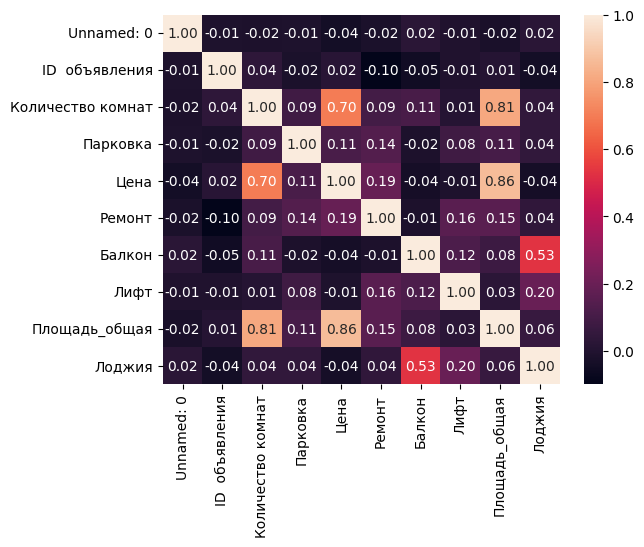

In [478]:
sns.heatmap(df.corr(numeric_only=True), fmt='.2f', annot=True)

In [479]:
def distance_to_subway(s) -> float:
    if pd.isna(s):
        return pd.NA

    # Проверяем, есть ли "(мин пешком)" или "(мин на машине)"
    minutes = 0
    if "мин пешком" in s:
        # ищем число минут перед " мин пешком"
        start = s.find("(") + 1
        end = s.find(" мин пешком")

        try :
            minutes = int(s[start:end])
        except:
            minutes = 0

        # Средняя скорость пешехода ≈ 5 км/ч = 5000 м/60 мин ≈ 83,33 м/мин.
        meters = int(minutes * 83.33)
        return meters

    elif "мин на машине" in s:
        start = s.find("(") + 1
        end = s.find(" мин на машине")
        try :
            minutes = int(s[start:end])
        except:
            minutes = 0

        # Средняя городская скорость ≈ 40 км/ч = 40000 м/60 мин ≈ 666,67 м/мин.
        meters = int(minutes * 666.67)
        return meters

    else:
        return 0

df['subway_distance'] = df['Метро'].apply(lambda x: distance_to_subway(x))
df[pd.isna(df['subway_distance'])].shape
df['subway_distance'].unique()

array([749, 666, 583, 249, 333, 833, 416, 166, 499, 999, 916, 0, 1249,
       <NA>, 2666, 16666, 1666, 6666, 9333, 7333, 4666, 10000, 1833, 1583,
       1416, 1499, 3333, 1166, 1083, 1916, 5333, 2249, 1999, 4000, 2916,
       2000, 6000, 2416, 83, 2083, 1333, 2499, 5249, 10666, 8000, 1749,
       20000, 11333, 9916, 2749, 2166, 2333, 2583, 13333, 14000, 3749,
       7666, 2833, 40000, 23333, 26666, 2999, 3166, 4999, 8666, 12000,
       3666, 3083, 16000, 3249, 15333, 12666, 4583, 4416, 3499, 3416,
       4749, 5166, 3916, 4166, 14666, 18000, 3999, 5666, 5083, 3583],
      dtype=object)

In [480]:
# Обработка Метро
def subway_name(s) -> (str) :
    if pd.isna(s) :
        return pd.NA
    
    # Check if string starts with 'м.'
    if s.startswith('м.'):
        # Remove 'м.' and strip
        remaining = s[2:].strip()

        # Split at first '(' to remove time part
        parts = remaining.split('(')
        station_name = parts[0].strip()
        return station_name

    else :
        print(">>>> Не начинается с м.", s)
        return pd.NA
    

df['Метро'] = df['Метро'].apply(lambda x: subway_name(x))
df[pd.isna(df['Метро'])].shape

(256, 16)

Справочник с координатами метро

In [481]:

# Subway station GPS data. (lat, lon)
subway_gps = {
    "Аэропорт": (55.79981, 37.53412),
    "Академическая": (55.68808, 37.57501),
    "Алексеевская": (55.80737, 37.63844),
    "Александровский сад": (55.75219, 37.60836),
    "Алтуфьево": (55.89504, 37.58605),
    "Аннино": (55.581818, 37.594978),
    "Арбатская": (55.75228, 37.60357),
    "Авиамоторная": (55.75208, 37.71677),
    "Автозаводская": (55.70801, 37.65858),
    "Бабушкинская": (55.86814, 37.66292),
    "Багратионовская": (55.74326, 37.49753),
    "Баррикадная": (55.76027, 37.58111),
    "Бауманская": (55.77228, 37.67857),
    "Беговая": (55.77378, 37.54412),
    "Белорусская": (55.77492, 37.58207),
    "Беляево": (55.64371, 37.52762),
    "Бибирево": (55.88294, 37.60523),
    "Библиотека им. Ленина": (55.75211, 37.60988),
    "Битцевский парк": (55.60029, 37.55735),
    "Боровицкая": (55.75034, 37.60857),
    "Ботанический сад": (55.84649, 37.63914),
    "Братеево": (55.631363, 37.75174),
    "Братиславская": (55.66126, 37.7509),
    "Говорово": (55.6607, 37.4176),
    "Чеховская": (55.76596, 37.6075),
    "Черкизовская": (55.802, 37.74438),
    "Чертаново": (55.63978, 37.60893),
    "Чистые пруды": (55.76426, 37.6389),
    "Чкаловская": (55.756218, 37.659375),
    "Динамо": (55.78867, 37.55936),
    "Бульвар Дмитрия Донского": (55.567759, 37.575724),
    "Дмитровская": (55.80756, 37.57959),
    "Добрынинская": (55.72886, 37.62356),
    "Долгопрудная": (55.93917, 37.52056),
    "Домодедовская": (55.61009, 37.71612),
    "Достоевская": (55.782438, 37.612747),
    "Дубровка": (55.719732, 37.676915),
    "Электрозаводская": (55.78177, 37.70471),
    "Шоссе энтузиастов": (55.75837, 37.75155),
    "Филевский парк": (55.73953, 37.48366),
    "Фили": (55.74673, 37.51384),
    "Фрунзенская": (55.72718, 37.58036),
    "Измайловская": (55.78768, 37.78329),
    "Улица Академика Янгеля": (55.596141, 37.59981),
    "Каховская": (55.65332, 37.59722),
    "Калужская": (55.65566, 37.53923),
    "Кантемировская": (55.6343, 37.65632),
    "Каширская": (55.65412, 37.64738),
    "Киевская": (55.74388, 37.56673),
    "Китай город": (55.75634, 37.63002),
    "Коломенское": (55.67745, 37.66298),
    "Комсомольская": (55.77717, 37.655689),
    "Коньково": (55.63253, 37.52005),
    "Кожуховская": (55.70533, 37.68508),
    "Красногвардейская": (55.614491, 37.744724),
    "Краснопресненская": (55.760109, 37.577141),
    "Красносельская": (55.780763, 37.666264),
    "Красные ворота": (55.76958, 37.6499),
    "Крестьянская застава": (55.732877, 37.668998),
    "Кропоткинская": (55.74525, 37.60463),
    "Крылатское": (55.75879, 37.40633),
    "Кунцевская": (55.73045, 37.44646),
    "Курская": (55.75848, 37.65985),
    "Кутузовская": (55.73947, 37.53433),
    "Кузьминки": (55.70531, 37.76775),
    "Кузнецкий мост": (55.76118, 37.62386),
    "Ленинский проспект": (55.70818, 37.58742),
    "Лубянка": (55.75876, 37.62573),
    "Люблино": (55.67694, 37.76316),
    "Марьина роща": (55.793602, 37.615762),
    "Марьино": (55.65193, 37.74771),
    "Марксистская": (55.7407, 37.65773),
    "Маяковская": (55.76909, 37.59635),
    "Медведково": (55.88594, 37.6612),
    "Менделеевская": (55.78251, 37.59792),
    "Минская": (55.731548, 37.491016),
    "Проспект мира": (55.781196, 37.633529),
    "Митино": (55.84589, 37.35909),
    "Молодежная": (55.74001, 37.41724),
    "Нагатинская": (55.68386, 37.62285),
    "Нагорная": (55.67283, 37.61019),
    "Нахимовский проспект": (55.66376, 37.60767),
    "Новые черемушки": (55.66892, 37.55417),
    "Новогиреево": (55.75111, 37.81564),
    "Новодачная": (55.92444, 37.52778),
    "Новокосино": (55.740539, 37.856347),
    "Новокузнецкая": (55.74212, 37.62901),
    "Новослободская": (55.77921, 37.6009),
    "Охотный ряд": (55.75703, 37.61614),
    "Октябрьское поле": (55.793615, 37.493496),
    "Октябрьская": (55.729, 37.61139),
    "Орехово": (55.61214, 37.69584),
    "Отрадное": (55.86417, 37.60488),
    "Парк культуры": (55.73512, 37.59328),
    "Парк Победы": (55.736559, 37.512591),
    "Партизанская": (55.78962, 37.7479),
    "Павелецкая": (55.7313, 37.63612),
    "Печатники": (55.69252, 37.7295),
    "Перово": (55.75109, 37.78854),
    "Первомайская": (55.79342, 37.79979),
    "Петровско-Разумовская": (55.83712, 37.57349),
    "Пионерская": (55.73583, 37.46731),
    "Планерная": (55.85931, 37.43687),
    "Площадь Ильича": (55.745663, 37.681123),
    "Улица Подбельского": (55.81503, 37.73209),
    "Улица Подбельского (2)": (55.81336, 37.73524),
    "Полежаевская": (55.77691, 37.51692),
    "Полянка": (55.73654, 37.61856),
    "Пражская": (55.61354, 37.60499),
    "Преображенская площадь": (55.79655, 37.71591),
    "Профсоюзная": (55.67822, 37.56381),
    "Пролетарская": (55.73171, 37.66726),
    "Пронская": (55.698344, 37.850869),
    "Пушкинская": (55.76565, 37.60417),
    "Речной вокзал": (55.85378, 37.47679),
    "Площадь Революции": (55.75646, 37.62321),
    "Рижская": (55.79222, 37.63557),
    "Римская": (55.746487, 37.682631),
    "Рязанский проспект": (55.71753, 37.79425),
    "Савеловская": (55.79421, 37.58666),
    "Щелковская": (55.80955, 37.79884),
    "Щукинская": (55.80796, 37.46629),
    "Семеновская": (55.78279, 37.71844),
    "Серпуховская": (55.72658, 37.62462),
    "Севастопольская": (55.65121, 37.59939),
    "Шаболовская": (55.71886, 37.60797),
    "Сходненская": (55.84937, 37.43951),
    "Славянский бульвар": (55.729508, 37.468829),
    "Смоленская": (55.74823, 37.58384),
    "Сокол": (55.80518, 37.51495),
    "Сокольники": (55.78893, 37.67943),
    "Солнцево":(55.6506, 37.3924),
    "Спортивная": (55.72397, 37.56547),
    "Сретенский бульвар": (55.765551, 37.635261),
    "Строгино": (55.80435, 37.396363),
    "Студенческая": (55.73873, 37.54825),
    "Сухаревская": (55.77211, 37.63239),
    "Площадь Суворова": (55.781984, 37.614487),
    "Свиблово": (55.85543, 37.65419),
    "Таганская": (55.74255, 37.65389),
    "Театральная": (55.75857, 37.6177),
    "Текстильщики": (55.70947, 37.73282),
    "Теплый стан": (55.61814, 37.50814),
    "Тимирязевская": (55.81842, 37.57571),
    "Третьяковская": (55.74061, 37.62492),
    "Трубная": (55.767605, 37.6221),
    "Царицино": (55.62011, 37.66939),
    "Цветной бульвар": (55.7716, 37.62058),
    "Тульская": (55.70901, 37.6226),
    "Тургеневская": (55.7646, 37.63623),
    "Тушинская": (55.8258, 37.43621),
    "Тверская": (55.7652, 37.60352),
    "Улица 1905 года": (55.76355, 37.56375),
    "Университет": (55.69167, 37.53433),
    "Варшавская": (55.65381, 37.62084),
    "ВДНХ": (55.82177, 37.64107),
    "Проспект Вернадского": (55.67613, 37.5045),
    "Владыкино": (55.84669, 37.59251),
    "Водный стадион": (55.8386, 37.48749),
    "Войковская": (55.81811, 37.49905),
    "Волоколамская": (55.83459, 37.38367),
    "Волгоградский проспект": (55.7243, 37.68795),
    "Волжская": (55.69101, 37.75498),
    "Воробьёвы горы": (55.710454, 37.558601),
    "Выхино": (55.715, 37.81802),
    "Ясенево": (55.60535, 37.53494),
    "Юго-Западная": (55.66464, 37.48421),
    "Южная": (55.62122, 37.60752),
    "Проспект Мира": (55.781196, 37.633529),
    "Боровское шоссе": (55.6473, 37.3722),
    "Коломенская": (55.67745, 37.66298),
    "Царицыно":	(55.62011, 37.66939),
    "Селигерская": (55.8667, 37.5471),
    "Лианозово": (55.8974, 37.5532),
    "Технопарк" : (55.6939, 37.6643),
    "Алма-Атинская" :(55.6328, 37.7661),
    "Зябликово": (55.6106, 37.7461),
    "Шипиловская": (55.6211, 37.7435),
    "Спартак": (55.8181, 37.4359),
    "Марк": (55.90389, 37.53833),
    "Площадь Гагарина": (55.7070, 37.5863),
    "Ховрино": (55.87917, 37.48333),
    "ЗИЛ": (55.6978, 37.6474),             
    "Крымская": (55.6904, 37.6042),
    "Верхние котлы": (55.69022, 37.61991),
    "Пятницкое шоссе": (55.855876, 37.354180),
    "Озёрная": (55.6506, 37.4175), 
    "Пенягино": (55.8230, 37.3612),
    "Битца": (55.60029, 37.55735), 
    "Трикотажная": (55.83306, 37.39833), 
    "Стрешнево": (55.8137, 37.4870),              
    "Покровское-Стрешнево": (55.822680, 37.442590),
    "Москворечье": (55.64556, 37.67528), 
    "Перерва": (55.66083, 37.71611),
    "Кубанская": (55.6875, 37.72639),   
    "Котельники": (55.6575, 37.8322),        
    "Чертановская": (55.63978, 37.60893),   
    "Лесопарковая": (55.6225, 37.5300),      
    "Окская": (55.6477, 37.7179),           
    "Озерная": (55.8386, 37.4845),          
    "Балтийская": (55.7065, 37.5475),
    "Коптево": (55.8235, 37.4910),  
    "Красный Балтиец": (55.8150, 37.5220),
    "Окружная": (55.8444, 37.5419),
    "Лихоборы": (55.8592, 37.5490),
    "Верхние Лихоборы": (55.8685, 37.5405),
    "Борисово": (55.6108, 37.7407),
    "Дегунино": (55.8670, 37.4620),
    "Улица Дмитриевского": (55.6647, 37.8692),
    "Косино": (55.7034168, 37.8510317),
    "Беломорская": (55.8736, 37.5169),
    "Ростокино": (55.8192, 37.6632), 
    "Выставочный центр": (55.8290, 37.6432),
    "Лухмановская": (55.70851, 37.9010164),
    "Мякинино": (55.8107, 37.3481), 
    "Улица Сергея Эйзенштейна": (55.8053, 37.3555), 
    "Мичуринский проспект": (55.7032, 37.4790), 
    "Давыдково": (55.7412, 37.4185), 
    "Бутырская": (55.8342, 37.5850),
    "Аминьевская": (55.7323, 37.4683),
    "Покровское": (55.7040, 37.6225),
    "Красный Строитель": (55.7170, 37.5290),
    "Рабочий поселок": (55.8456, 37.5878),    
    "Раменки": (55.6937, 37.5105),    
    "Ломоносовский проспект": (55.6996, 37.5110),
    "Новые Черемушки": (55.66892, 37.55417),  
    "Сетунь": (55.6931, 37.4476),              
    "Выставочная": (55.7473, 37.5369),  
    "Некрасовка": (55.6843, 37.8385), 
    "Депо": (55.90389, 37.53833),        
    "Локомотив": (55.8173, 37.5158),  
    "Шелепиха": (55.7546, 37.5331),   
    "Тропарево": (55.6510, 37.4826),     
    "Новаторская": (55.6341, 37.4906),    
    "Новопеределкино": (55.6212, 37.4327),
    "Соколиная гора": (55.7866, 37.7748), 
    "Измайлово": (55.7582, 37.8117),       
    "Павшино": (55.8467, 37.2649),
    "Лефортово": (55.7405, 37.6862),       
    "Шоссе Энтузиастов": (55.75837, 37.75155), 
    "Теплый Стан": (55.61814, 37.50814),
    "Панфиловская": (55.8462, 37.3608),  
    "Зорге": (55.8454, 37.3675),  
    "Петровский Парк": (55.7777, 37.5592),
    "Международная": (55.7461, 37.5362),
    "Деловой центр": (55.7471, 37.5365),
    "Тестовская": (55.7572, 37.5319),
    "Парк Культуры": (55.73512, 37.59328),
    "Лужники": (55.7208, 37.5566),
    "Китай-город": (55.75634, 37.63002),
    "Улица Старокачаловская": (55.5884, 37.4682),
    "Юго-Восточная": (55.63023, 37.75015),
    "Жулебино": (55.685438, 37.8562939),
    "Лермонтовский проспект": (55.62421, 37.81099),
    "Стахановская": (55.61172, 37.72603),
    "Фонвизинская": (55.8485, 37.5822),
    "Улица Академика Королева": (55.8389, 37.6381),
    "Улица Милашенкова": (55.8295, 37.6371),
    "Белокаменная": (55.8167, 37.6667),
    "Бульвар Рокоссовского": (55.8256, 37.7085),
    "Угрешская": (55.6783, 37.7341),
    "Нижегородская": (55.7128, 37.7517),
    "Курьяново": (55.6572, 37.7128),
    "Калитники": (55.6995, 37.7489),
    "Народное ополчение": (55.8037, 37.4501),
    "улица Народного ополчения": (55.8037, 37.4501),
    "Хорошево": (55.7848, 37.4941),
    "Воробьевы горы": (55.710454, 37.558601),
    "Андроновка": (55.7359, 37.7938),
    "Рассказовка": (55.6266, 37.4366),         
    "Саларьево": (55.6108, 37.3373),          
    "Новохохловская": (55.7322, 37.7099),
    "Телецентр": (55.7945, 37.6965),       
    "Москва-Товарная": (55.7330, 37.6720),  
    "Зюзино": (55.6485, 37.5398),            
    "Яхромская": (55.7894, 37.7413),      
    "Бескудниково": (55.8781, 37.4786),
    "Воронцовская": (55.6500, 37.6233), 
    "Мневники": (55.7873, 37.4290),      
    "Румянцево": (55.5943, 37.4188),
    "Новоясеневская": (55.6147, 37.5173),  
    "Гражданская": (55.8150, 37.5003),     
    "Нахабино": (55.8467, 37.1753), 
    "Каланчёвская": (55.7765, 37.6621),       
    "Щербинка": (55.5011, 37.5539),  
    "Улица Скобелевская": (55.5853, 37.5148), 
    "Улица Горчакова": (55.5856, 37.4830), 
    "Бунинская аллея": (55.5746, 37.4728),
    "Бутово": (55.5832, 37.6021), 
    "Бульвар Адмирала Ушакова": (55.5676, 37.5385), 
    "Сколково": (55.7050, 37.3412),  
    "Немчиновка": (55.7252, 37.3323), 
    "ЦСКА": (55.7650, 37.5360),
    "Хорошевская": (55.7965, 37.5358),
    "Лермонтовский проспект" :(55.7016254, 37.8519732),
    "Улица Дмитриевского":  (55.7101029, 37.8802008),
}

def get_subway_location(station_name) -> tuple : #(lat, lon)
    if pd.isna(station_name) :
        return pd.NA
    
    if station_name in subway_gps:
        lat_lon =  subway_gps.get(station_name)
        # print(station_name, lat_lon)
        return lat_lon
    
    print(">>>>> Нет станции", station_name)
    return pd.NA

In [482]:
# Метро на основе загруженного geojson, но там не хватает станций
import json

with open("datasets/metro.geojson") as f:
    data = json.load(f)

stations = {}

for feature in data["features"]:
    name = feature["properties"]["name"]
    lon, lat = feature["geometry"]["coordinates"]
    stations[name] = (lon, lat)

print(len(stations), len(subway_gps))


possibly_wrong_gps = ['Новодачная', 'Долгопрудная','Мякинино', 'Улица Сергея Эйзенштейна', 'Лермонтовский проспект',                 'Жулебино',
                   'Косино','Лухмановская', 'Улица Дмитриевского','Сколково', 'Немчиновка','Нахабино','Павшино']

for subway in possibly_wrong_gps :
    if subway in stations :
        print(subway, stations[subway])

237 294
Лермонтовский проспект (37.8519732, 55.7016254)
Жулебино (37.8562939, 55.685438)
Косино (37.8510317, 55.7034168)
Лухмановская (37.9010164, 55.70851)
Улица Дмитриевского (37.8802008, 55.7101029)


In [483]:
# Добавить lat, lon  по метро
df[['lat', 'lon']] = df['Метро'].apply(lambda x: pd.Series(get_subway_location(x)))
df.head(2)


,Unnamed: 0,ID объявления,Количество комнат,Метро,Адрес,Парковка,Цена,Ремонт,Балкон,Лифт,тип_дома,этаж_квартиры,этажность_дома,Площадь_общая,Лоджия,subway_distance,lat,lon
0,0,271271157,4,Смоленская,"улица Новый Арбат, 27",1,500000,4,0,1,Монолитный,5,16,200.0,0,749,55.74823,37.58384
1,1,271634126,4,Смоленская,"улица Новый Арбат, 27",1,500000,4,0,1,Монолитно-кирпичный,5,16,198.0,0,666,55.74823,37.58384


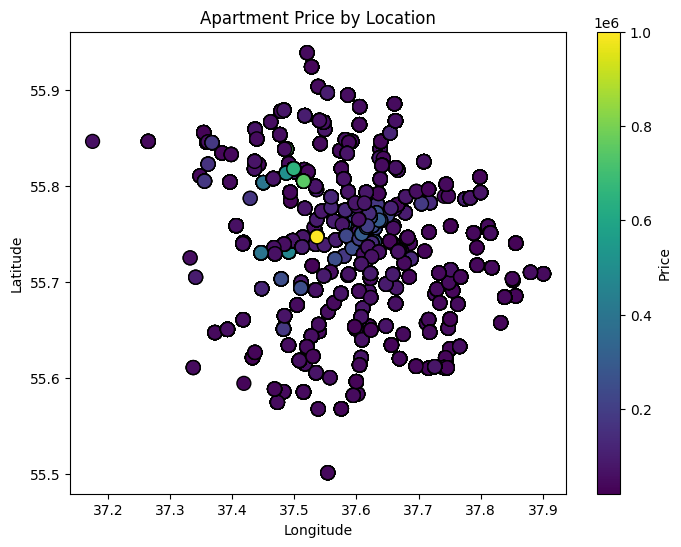

In [484]:
# функция, чтобы расположение квартир на карте
lat_lon = df['Метро'].apply(lambda x: get_subway_location(x))

# create heat map based on (lat, lon) & price
lat = lat_lon.apply(lambda x: pd.NA if pd.isna(x) else x[0])
lon = lat_lon.apply(lambda x: pd.NA if pd.isna(x) else x[1])
price = df['Цена']

# Filter out rows with missing lat, lon, or price
mask = lat.notna() & lon.notna() & price.notna()
lat = lat[mask]
lon = lon[mask]
price = price[mask]

# Scatter plot
plt.figure(figsize=(8,6))
plt.title('Apartment Price by Location')
scatter = plt.scatter(lon, lat, c=price, cmap='viridis', s=100, edgecolor='k')
cbar = plt.colorbar(scatter)
cbar.set_label('Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')



plt.show()

In [485]:
# Метро в Округ(не хватает 3 округов)

import geopandas as gpd
from shapely.geometry import Point

# Загрузить полигоны районов
districts = gpd.read_file("datasets/moscow.geo.json")

# Преобразовать координаты в точки
#37.6173 , 55.7558 – Moscow center

# ЗелАО
# ВАО
# САО
# ЮЗАО
# ЮВАО
# ТАО
# ЮАО
# СВАО
# ЦАО

#ЗАО #Западный административный округ.
#НАО #Новомосковский административный округ.
#TAO # Троицкий

def get_district(lon, lat) -> str :
    point = gpd.GeoSeries([Point((lon,lat))])  # lon, lat

    for i, district in districts.iterrows():

        if district['geometry'].contains(point[0]):
            return district['ref']

In [486]:
# Метро в Округ

def subway_to_district(station_name) -> str :
    if pd.isna(station_name) :
        return pd.NA
    
    lat_lon = get_subway_location(station_name)
    
    if pd.isna(lat_lon) or len(lat_lon) < 2 :
        return pd.NA

    lat = lat_lon[0]
    lon = lat_lon[1]

    return get_district(lon , lat)

In [487]:
# добавим округ в столбцы
df['Округ'] = df['Метро'].apply(lambda х: subway_to_district(х))
df[pd.isna(df['Округ'])].shape

(347, 19)

In [488]:
# добавим округ
zelenograd_no_subway = df[pd.isna(df['Метро'])]['Адрес'][df['Адрес'].str.startswith("Зеленоград")]


In [489]:
# создаем маску: Адрес начинается с "Зеленоград" и Метро не заполнено
mask = df['Адрес'].str.startswith("Зеленоград") & df['Метро'].isna()

# присваиваем lat и lon для этих строк, 
# они будут без метро но с примерным лат, лон
df.loc[mask, 'Округ'] = 'ЗелАО'
df.loc[mask, 'lat'] = 55.9825
df.loc[mask, 'lon'] = 37.18139

df.loc[mask, 'subway_distance'] = 25000
df[pd.isna(df['Округ'])].shape

(265, 19)

In [490]:
# проверяем ст.метро которые не отнеслись ни к какому округу
df[pd.isna(df['Округ']) & df['Метро'].notna()]['Метро'].unique()


<StringArray>
[              'Новодачная',             'Долгопрудная',
                 'Мякинино', 'Улица Сергея Эйзенштейна',
                 'Сколково',               'Немчиновка',
                 'Нахабино',                  'Павшино']
Length: 8, dtype: str

In [491]:
# обрабатка ст.метро которые не отнеслись ни к какому округу
station_to_okrug = {
    "Новодачная": "СВАО",
    "Долгопрудная": "СВАО",
    "Мякинино": "ЗелАО",
    "Улица Сергея Эйзенштейна": "СВАО",
    "Сколково": "ЗАО",
    "Немчиновка": "ЗАО",
    "Нахабино": "ЗАО",
    "Павшино": "ЗАО"
}

mask = df['Округ'].isna()  # строки, где Округ пустой
df.loc[mask, 'Округ'] = df.loc[mask, 'Метро'].map(station_to_okrug)

df[pd.isna(df['Округ']) & df['Метро'].notna()]['Метро'].unique()

<StringArray>
[]
Length: 0, dtype: str

In [492]:
print(df[pd.isna(df['Округ'])].shape)
print(df[pd.isna(df['Метро'])].shape)

(174, 19)
(256, 19)


In [493]:
# 194 адреса без лат и лон можно убрать
missing_lat_addresses = df.loc[pd.isna(df['lat']), 'Адрес'].tolist()
print(missing_lat_addresses)

df.dropna(subset=['lat'], inplace=True)
print(df.loc[pd.isna(df['Округ'])].shape, df.loc[pd.isna(df['Метро'])].shape)
print(df.loc[pd.isna(df['lat'])].shape, df.loc[pd.isna(df['lon'])].shape)

['улица Новый Арбат, 29', '9-я Северная линия, 1К1', 'бульвар Академика Ландау, 3', 'Дмитровское шоссе, 165Дк6', 'улица Академика Янгеля, 2', 'Бирюлевская улица, 53/1', 'Лебедянская улица, 36К1', 'Синявинская улица, 11к16', 'Синявинская улица, 11к5', 'Синявинская улица, 11к3', 'Юго-Восточный ао, Кузьминки р-н, Волжский Бульвар 114А кв-л, к6', 'Большая Академическая улица, 8К1', 'Строгинский бульвар, 30', 'Кронштадтский бульвар, 28', 'Ленинградское шоссе, 66', 'улица Москворечье, 4к6', 'Каширский проезд, 25к1', 'улица Сергея Эйзенштейна, 6к2с2', 'Озерная улица, 13', 'Веерная улица, 3К6', 'улица Наташи Ковшовой, 23', '11-я Парковая улица, 48К3', 'Полярная улица, 27к5', 'Изумрудная улица, 42', 'Ярославское шоссе, 146к2', 'Волгоградский проспект, 197', 'Волгоградский проспект, 187/16', 'улица Ляпидевского, 8К2', 'Левобережная улица, 4к15', 'Тюменский проезд, 3к1', 'Луганская улица, 3К1', 'проспект Маршала Жукова, 39к6', 'Карамышевская набережная, 11С1', 'Шелепихинская набережная, 34к1', 'Н

In [494]:
df['lat']=df['lat'].astype(float)
df['этаж_квартиры']=df['этаж_квартиры'].astype(int)
df['этажность_дома']=df['этажность_дома'].astype(int)
df['subway_distance']=df['subway_distance'].astype(int)

df.drop('Метро', axis=1, inplace=True)
df.drop('Адрес', axis=1, inplace=True)

In [495]:
df.info()

<class 'pandas.DataFrame'>
Index: 17984 entries, 0 to 23367
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         17984 non-null  int64  
 1   ID  объявления     17984 non-null  int64  
 2   Количество комнат  17984 non-null  Int64  
 3   Парковка           17984 non-null  int64  
 4   Цена               17984 non-null  int64  
 5   Ремонт             17984 non-null  int64  
 6   Балкон             17984 non-null  int64  
 7   Лифт               17984 non-null  int64  
 8   тип_дома           17984 non-null  str    
 9   этаж_квартиры      17984 non-null  int64  
 10  этажность_дома     17984 non-null  int64  
 11  Площадь_общая      17984 non-null  float64
 12  Лоджия             17984 non-null  int64  
 13  subway_distance    17984 non-null  int64  
 14  lat                17984 non-null  float64
 15  lon                17984 non-null  float64
 16  Округ              17984 non-null  str

In [496]:
# кодирование через координаты -> результат новая колонка с расстоянием до центра
def haversine_distance(lat1, lon1, lat2, lon2):
    # Радиус Земли в километрах
    r = 6371 
    
    # Перевод в радианы
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    # Формула гаверсинуса
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    res = 2 * r * np.arcsin(np.sqrt(a))
    return res

# Координаты центра Москвы (Кремль)
MOSCOW_CENTER = (55.7522, 37.6175)

# Создание нового признака
df['dist_to_center'] = haversine_distance(
    df['lat'], df['lon'], 
    MOSCOW_CENTER[0], MOSCOW_CENTER[1]
)

In [498]:
df.rename(columns ={
    'ID  объявления': 'id',
    'Количество комнат': 'number_of_rooms',
    'Парковка': 'parking',
    'Цена': 'price',
    'Лифт': 'elevator',
    'тип_дома': 'type',
    'этаж_квартиры': 'floor',
    'этажность_дома': 'number_of_floors',
    'Площадь_общая': 'square',
    'Ремонт': 'condition',
    'Балкон': 'balcony',
    'Лоджия': 'loggia',
    'Округ': 'county'
}, inplace=True)

In [ ]:
#шифрование округов
county_to_num ={
"ТАО": 1, # Троицкий АО – самые низкие цены
"НАО": 2, # Новомосковский АО
"ЗелАО": 3, # Зеленоград
"ЮВАО": 4, # Юго-Восточный АО
"ЮАО": 5, # Южный АО
"ВАО": 6,# Восточный АО
"СВАО": 7, # Северо-Восточный АО
"САО": 8,# Северный АО
"СЗАО": 9, #Северо-Западный АО
"ЮЗАО": 10,# Юго-Западный АО
"ЗАО": 11,# Западный АО
"ЦАО": 12# Центральный АО – самые высокие цены
}

df['county'] = df['county'].map(county_to_num)

In [509]:
type_to_num ={
    'Неизвестен': 0,
    'Щитовой': 1,
    'Деревянный': 2,
    'Блочный': 3,
    'Панельный': 4,
    'Монолитный': 5,
    'Монолитно-кирпичный': 6,
    'Кирпичный': 7,
    'Сталинский': 8,
    'старый фонд': 9
}

df['type'] = df['type'].map(type_to_num)

In [511]:
df.info()

<class 'pandas.DataFrame'>
Index: 17984 entries, 0 to 23367
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17984 non-null  int64  
 1   id                17984 non-null  int64  
 2   number_of_rooms   17984 non-null  Int64  
 3   parking           17984 non-null  int64  
 4   price             17984 non-null  int64  
 5   condition         17984 non-null  int64  
 6   balcony           17984 non-null  int64  
 7   elevator          17984 non-null  int64  
 8   type              17984 non-null  int64  
 9   floor             17984 non-null  int64  
 10  number_of_floors  17984 non-null  int64  
 11  square            17984 non-null  float64
 12  loggia            17984 non-null  int64  
 13  subway_distance   17984 non-null  int64  
 14  lat               17984 non-null  float64
 15  lon               17984 non-null  float64
 16  county            17984 non-null  int64  
 17  dist_to_c

In [ ]:
df['price_sqm']= df['price']/df['square']

<class 'pandas.DataFrame'>
Index: 17984 entries, 0 to 23367
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17984 non-null  int64  
 1   id                17984 non-null  int64  
 2   number_of_rooms   17984 non-null  Int64  
 3   parking           17984 non-null  int64  
 4   price             17984 non-null  int64  
 5   condition         17984 non-null  int64  
 6   balcony           17984 non-null  int64  
 7   elevator          17984 non-null  int64  
 8   type              17984 non-null  int64  
 9   floor             17984 non-null  int64  
 10  number_of_floors  17984 non-null  int64  
 11  square            17984 non-null  float64
 12  loggia            17984 non-null  int64  
 13  subway_distance   17984 non-null  int64  
 14  lat               17984 non-null  float64
 15  lon               17984 non-null  float64
 16  county            17984 non-null  int64  
 17  dist_to_c

In [519]:
#сохранение DataFrame
df.to_csv('data.csv')

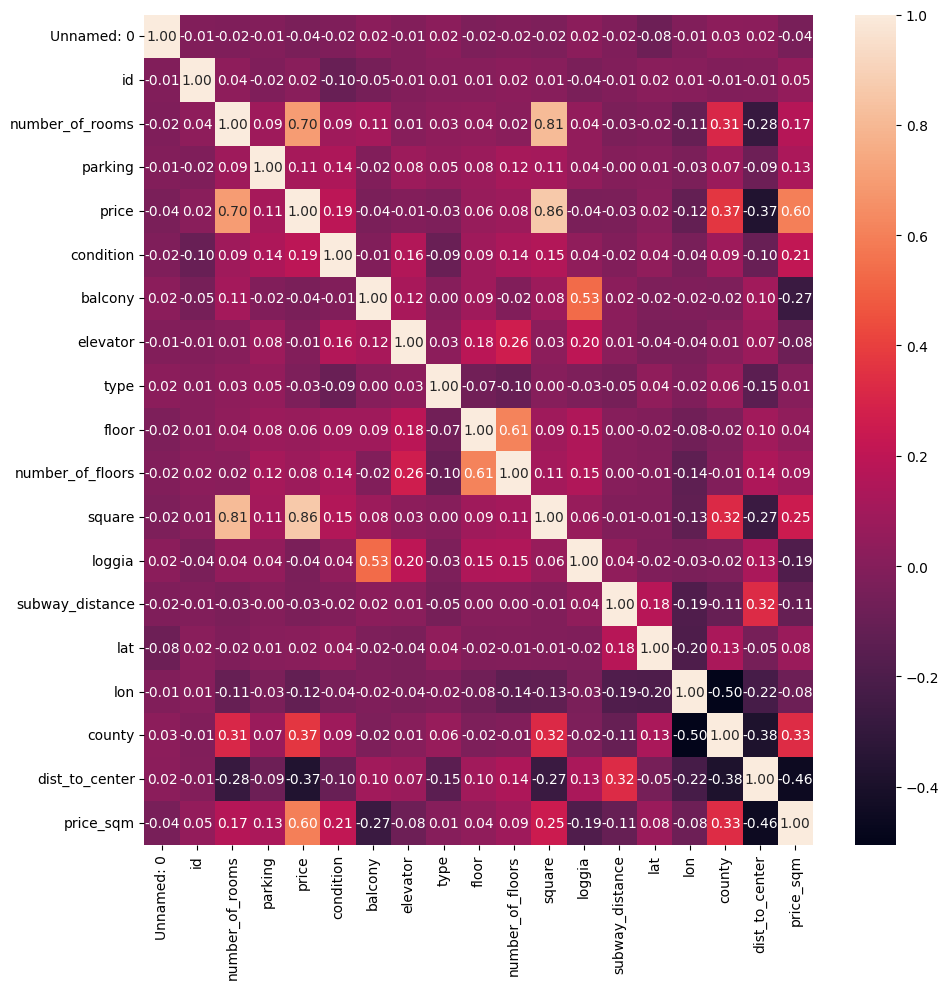

In [520]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(numeric_only=True), fmt='.2f', annot=True)
plt.tight_layout()
plt.show()

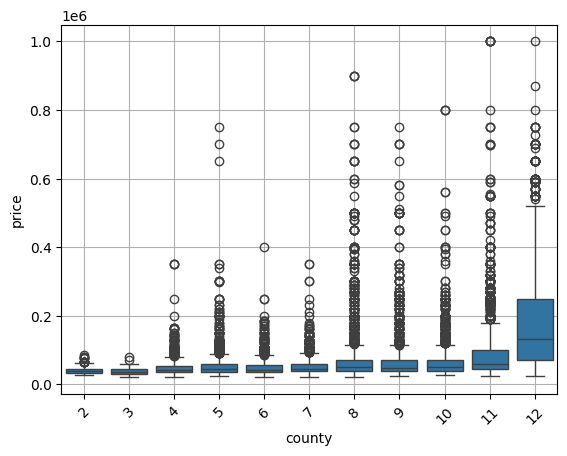

In [516]:
sns.boxplot(data=df, x='county', y = 'price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
